> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


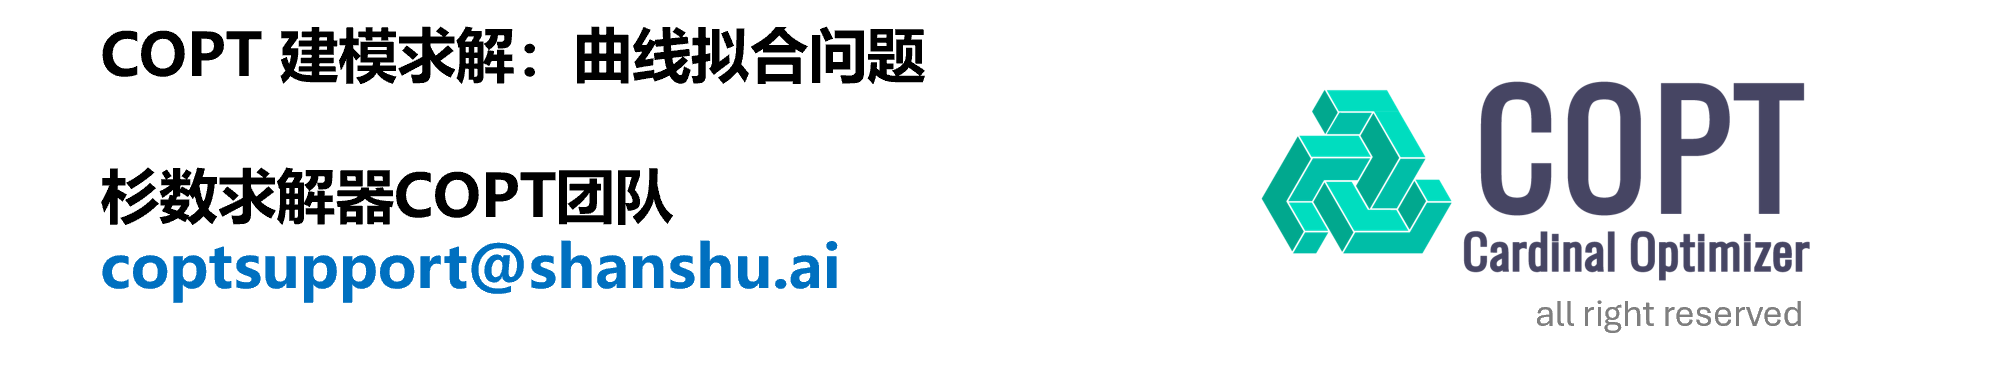

# 曲线拟合问题代码实现
## 使用COPT建模求解曲线拟合问题的步骤

1. **导入COPT-Python接口库** `coptpy`

2. **导入数据**
   - 导入点的坐标

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
   - **决策变量**：
      - 最终拟合模型的系数
   - **目标函数**：最小化损失函数
   - **约束条件**：
      - 无约束

5. **求解**

6. 查看、分析**结果**

## 导入COPT-Python接口库

In [4]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt
import numpy as np
import random

plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 添加模型数据

In [6]:
# 设定随机数种子便于复现
random.seed(42)
np.random.seed(42)

# 设定模型次数
model_degree = 4

# 设定最高拟合次数
max_degree = 9

# 生成随机函数
coeff = [(random.random() - 0.5) * (i + 2) * (i + 3) * (i + 4) for i in range(model_degree + 1)]
print(coeff)

# 设定点的数量
num_points = 20
points_x = [random.random() * 10 - 5 for _ in range(num_points)]
points_y = []
for i in range(num_points):
    points_y.append(coeff[0])
    for j in range(model_degree):
        points_y[-1] *=  points_x[i]
        points_y[-1] += coeff[j + 1]
    points_y[-1] += np.random.normal(0, 750)

print(points_y)


[3.34624316298921, -28.499354686639986, -26.99648179570569, -58.125744988747215, 79.45432795910817]
[140.38083986848352, -1594.891025355613, 3327.357652911409, 1265.4613637356363, 4178.680875280102, 698.1810174524855, 1260.6693654263836, 5031.388241375517, 711.2788403830416, 259.52941407666714, -302.13447119057435, 508.7223752728727, 169.38097500341297, -2331.4339101699256, 3825.216046986452, -1294.9456618869076, -1071.4406294387893, 477.0794728909642, 915.1029371238966, -3071.490197479746]


## 创建求解环境和求解模型

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量

In [10]:
A = model.addVars(max_degree + 1, lb=-COPT.INFINITY, nameprefix='A')

### 设置目标函数
最小化损失函数
$$
    \min \quad \sum_{i = 1}^{\text{num}_\text{points}}(y_i - \sum_{j = 0}^{\text{max}_\text{degree}}a_j\cdot x_i^j)^2
$$

In [12]:
predict_num = []
for i in range(num_points):
    predict_num.append(A[0])
    for j in range(max_degree):
        predict_num[-1] *= points_x[i]
        predict_num[-1] += A[j + 1]

model.setObjective(cp.quicksum((points_y[i] - predict_num[i]) * (points_y[i] - predict_num[i]) for i in range(num_points)), sense=COPT.MINIMIZE)

### 添加约束条件
该问题为无约束优化问题

## 求解

In [15]:
# 关闭日志显示
model.setParam(COPT.Param.Logging, False)

model.solve()

## 获取结果


9次模型相关信息
最小误差为2964402.11
常数项: 676.67
1次项系数: -419.83
2次项系数: 9.13
3次项系数: 50.07
4次项系数: -64.23
5次项系数: -8.89
6次项系数: 6.94
7次项系数: 0.53
8次项系数: -0.19
9次项系数: -0.01

8次模型相关信息
最小误差为2996578.26
常数项: 686.36
1次项系数: -321.15
2次项系数: -20.72
3次项系数: -10.05
4次项系数: -55.37
5次项系数: 1.08
6次项系数: 6.15
7次项系数: -0.09
8次项系数: -0.16

7次模型相关信息
最小误差为4029004.97
常数项: 973.75
1次项系数: -419.39
2次项系数: -449.25
3次项系数: 63.29
4次项系数: 42.19
5次项系数: -7.8
6次项系数: -1.02
7次项系数: 0.19

6次模型相关信息
最小误差为4275607.28
常数项: 1000.21
1次项系数: -207.08
2次项系数: -510.64
3次项系数: -12.97
4次项系数: 51.19
5次项系数: -0.69
6次项系数: -1.33

5次模型相关信息
最小误差为6428730.91
常数项: 595.24
1次项系数: -109.12
2次项系数: -167.84
3次项系数: -37.67
4次项系数: 7.76
5次项系数: 0.45

4次模型相关信息
最小误差为6471774.77
常数项: 602.37
1次项系数: -177.74
2次项系数: -163.46
3次项系数: -25.03
4次项系数: 7.42

3次模型相关信息
最小误差为8790165.93
常数项: 148.13
1次项系数: -69.45
2次项系数: -1.59
3次项系数: -33.68

2次模型相关信息
最小误差为17513669.91
常数项: 87.83
1次项系数: -583.31
2次项系数: 23.76

1次模型相关信息
最小误差为18145225.77
常数项: 302.01
1次项系数: -605.79


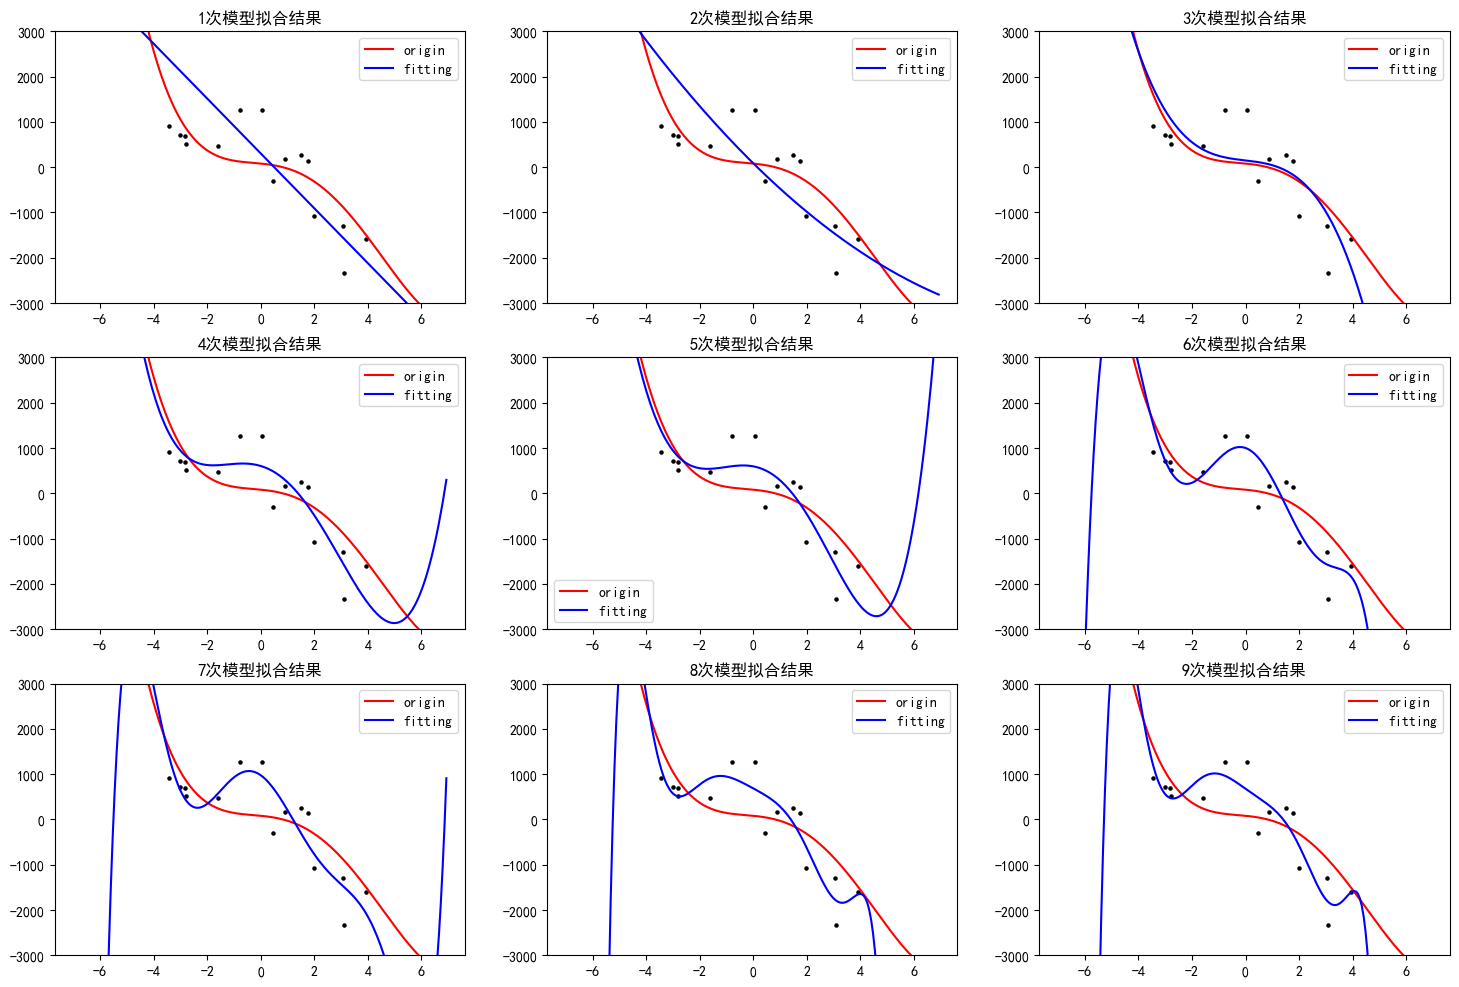

In [17]:
# 设定子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 重复九次求解九个模型分别拟合1次到9次函数
for i in range(9, 0, -1):
    # 九次模型不需要加约束
    if i < 9:
        model.addConstr(A[8 - i] == 0)
    model.solve()
    print(f'\n{i}次模型相关信息')
    if model.status == COPT.OPTIMAL:
        print(f'最小误差为{round(model.objval, 2)}')
        variables = model.getVars()
        print(f'常数项: {round(variables[9].x, 2)}')
        for j in range(1, i + 1):
            print(f'{j}次项系数: {round(variables[9 - j].x, 2)}')
        # 绘制子图
        sub = axs[int((i - 1) / 3), (i - 1) % 3]
        # 绘制点
        sub.scatter(points_x, points_y, c='black', s=5)
        # 绘制曲线
        max_x = 7
        min_x = -7
        num_points_cal = 200
        x_origin = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_origin = []
        for k in range(num_points_cal):
            y_origin.append(coeff[0])
            for j in range(model_degree):
                y_origin[-1] *= x_origin[k]
                y_origin[-1] += coeff[j + 1]
        sub.plot(x_origin, y_origin, c='red', label='origin')
        x_cal = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_cal = []
        for k in range(num_points_cal):
            y_cal.append(A[0].x)
            for j in range(max_degree):
                y_cal[-1] *= x_cal[k]
                y_cal[-1] += A[j + 1].x
        sub.plot(x_cal, y_cal, c='blue', label='fitting')
        sub.set_title(f'{i}次模型拟合结果')
        sub.legend()
        sub.set_ylim(-3000, 3000)
    else:
        print('未找到最优解')
plt.show()

> 可以发现，高次的模型过拟合程度较为严重

# 案例拓展
## 岭回归（L2 正则化）
目标函数变为以下形式
$$
    \min \quad \sum_{i = 1}^{\text{num}_\text{points}}(y_i - \sum_{j = 0}^{\text{max}_\text{degree}}a_j\cdot x_i^j)^2 + \sum_{j = 0}^{\text{max}_\text{degree}}a_j^2
$$


9次模型相关信息
最小误差为7365385.56
常数项: 1.05
1次项系数: -1.49
2次项系数: -2.39
3次项系数: -4.18
4次项系数: -16.06
5次项系数: -5.38
6次项系数: 1.94
7次项系数: 0.24
8次项系数: -0.05
9次项系数: -0.0

8次模型相关信息
最小误差为7386176.63
常数项: 1.06
1次项系数: -1.67
2次项系数: -2.23
3次项系数: -4.9
4次项系数: -14.97
5次项系数: -4.45
6次项系数: 1.77
7次项系数: 0.14
8次项系数: -0.05

7次模型相关信息
最小误差为8172365.92
常数项: 0.83
1次项系数: -1.15
2次项系数: -2.26
3次项系数: -2.01
4次项系数: -3.52
5次项系数: -5.48
6次项系数: 0.24
7次项系数: 0.19

6次模型相关信息
最小误差为10775255.59
常数项: 0.64
1次项系数: -3.69
2次项系数: -2.98
3次项系数: -23.33
4次项系数: 0.41
5次项系数: -0.6
6次项系数: 0.01

5次模型相关信息
最小误差为10776275.79
常数项: 0.61
1次项系数: -3.67
2次项系数: -3.16
3次项系数: -23.19
4次项系数: 0.62
5次项系数: -0.61

4次模型相关信息
最小误差为11370348.58
常数项: 0.45
1次项系数: -3.06
2次项系数: -4.67
3次项系数: -34.54
4次项系数: 1.02

3次模型相关信息
最小误差为11829566.81
常数项: 0.86
1次项系数: -2.75
2次项系数: 5.49
3次项系数: -35.91

2次模型相关信息
最小误差为76378600.31
常数项: 1.7
1次项系数: -48.26
2次项系数: 47.62

1次模型相关信息
最小误差为87850183.97
常数项: 6.17
1次项系数: -54.46


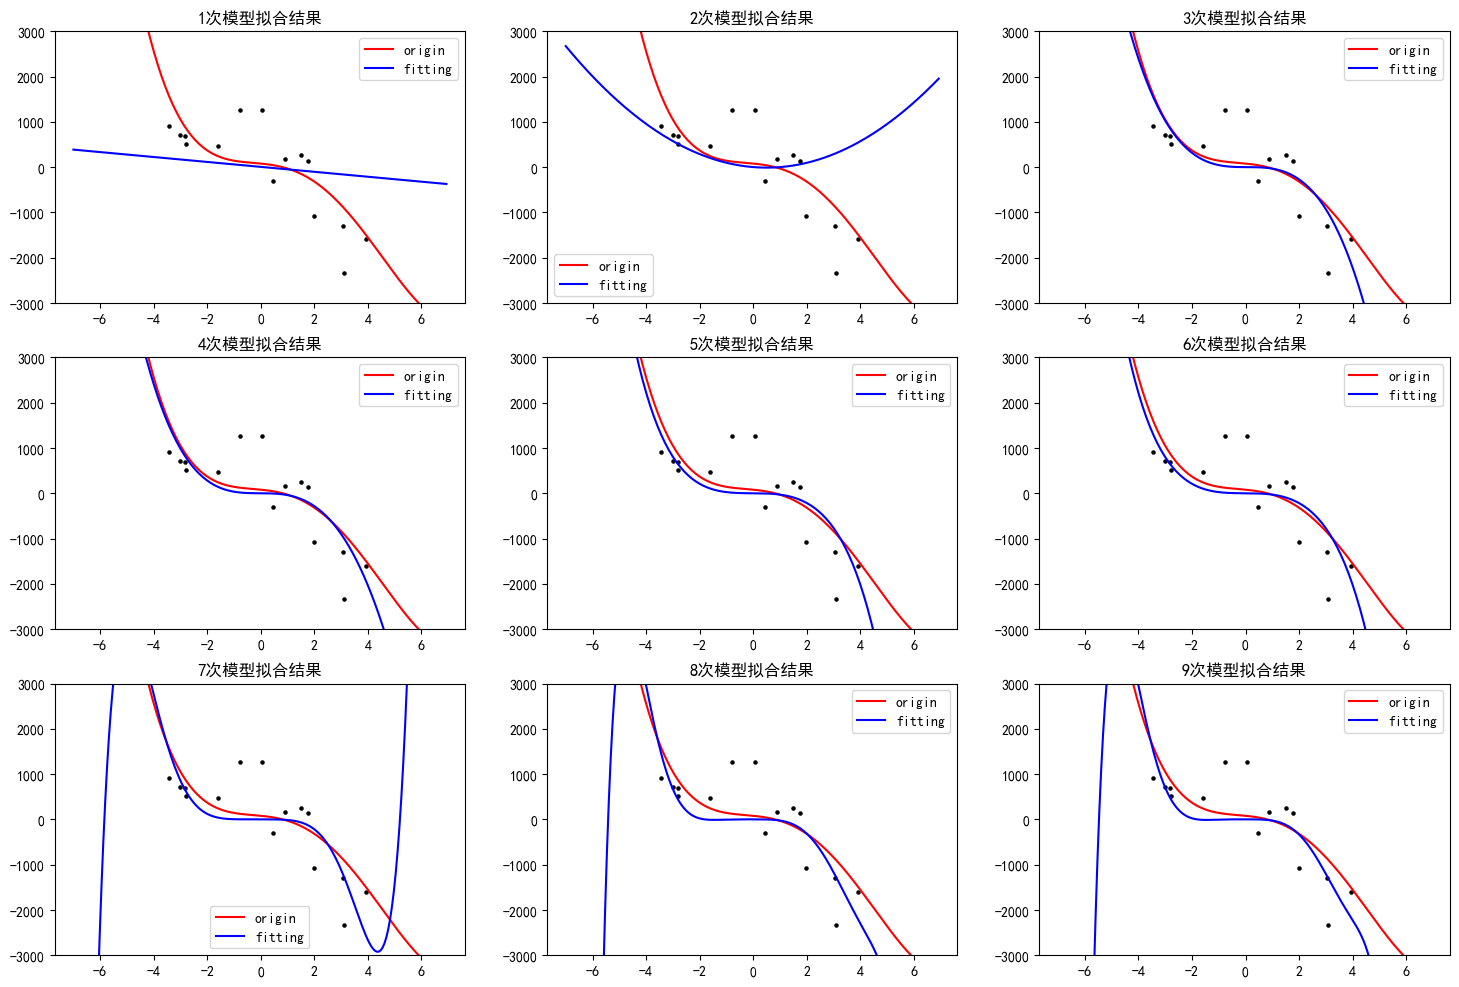

In [20]:
# 清除加入的约束
model.remove(model.getConstrs())

# 设定 lambda 控制正则化强度
lbd = 2000

# 改变约束，添加正则化项
model.setObjective(cp.quicksum((points_y[i] - predict_num[i]) * (points_y[i] - predict_num[i]) for i in range(num_points))
                   + cp.quicksum(A[i] * A[i] for i in range(10)) * lbd, sense=COPT.MINIMIZE)

# 设定子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 重复九次求解九个模型分别拟合1次到9次函数
for i in range(9, 0, -1):
    # 九次模型不需要加约束
    if i < 9:
        model.addConstr(A[8 - i] == 0)
    model.solve()
    print(f'\n{i}次模型相关信息')
    if model.status == COPT.OPTIMAL:
        print(f'最小误差为{round(model.objval, 2)}')
        variables = model.getVars()
        print(f'常数项: {round(variables[9].x, 2)}')
        for j in range(1, i + 1):
            print(f'{j}次项系数: {round(variables[9 - j].x, 2)}')
        # 绘制子图
        sub = axs[int((i - 1) / 3), (i - 1) % 3]
        # 绘制点
        sub.scatter(points_x, points_y, c='black', s=5)
        # 绘制曲线
        max_x = 7
        min_x = -7
        num_points_cal = 200
        x_origin = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_origin = []
        for k in range(num_points_cal):
            y_origin.append(coeff[0])
            for j in range(model_degree):
                y_origin[-1] *= x_origin[k]
                y_origin[-1] += coeff[j + 1]
        sub.plot(x_origin, y_origin, c='red', label='origin')
        x_cal = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_cal = []
        for k in range(num_points_cal):
            y_cal.append(A[0].x)
            for j in range(max_degree):
                y_cal[-1] *= x_cal[k]
                y_cal[-1] += A[j + 1].x
        sub.plot(x_cal, y_cal, c='blue', label='fitting')
        sub.set_title(f'{i}次模型拟合结果')
        sub.legend()
        sub.set_ylim(-3000, 3000)
    else:
        print('未找到最优解')
plt.show()

## Lasso回归（L1正则化）
目标函数变为以下形式
$$
    \min \quad \sum_{i = 1}^{\text{num}_\text{points}}(y_i - \sum_{j = 0}^{\text{max}_\text{degree}}a_j\cdot x_i^j)^2 + \sum_{j = 0}^{\text{max}_\text{degree}}|a_j|
$$
考虑到其绝对值的形式，添加辅助变量$b$，以及约束
$$
\begin{aligned}
    b_j & \geq a_j, \, \forall \, j \\
    b_j &\geq -a_j \, \forall \, j
\end{aligned}
$$
此时，由于最小化的优化方向, $b_j=|a_j|, \, \forall \, j$会自动成立



9次模型相关信息
最小误差为3619349.82
常数项: 617.33
1次项系数: -93.18
2次项系数: 0.0
3次项系数: -62.32
4次项系数: -59.58
5次项系数: 4.29
6次项系数: 6.53
7次项系数: -0.11
8次项系数: -0.18
9次项系数: -0.0

8次模型相关信息
最小误差为3619933.04
常数项: 615.2
1次项系数: -80.49
2次项系数: -0.0
3次项系数: -70.23
4次项系数: -59.18
5次项系数: 5.59
6次项系数: 6.47
7次项系数: -0.19
8次项系数: -0.17

7次模型相关信息
最小误差为5506887.8
常数项: 824.0
1次项系数: -150.34
2次项系数: -389.89
3次项系数: 0.0
4次项系数: 36.57
5次项系数: -3.43
6次项系数: -0.88
7次项系数: 0.1

6次模型相关信息
最小误差为5618808.85
常数项: 843.26
1次项系数: -58.75
2次项系数: -423.43
3次项系数: -35.92
4次项系数: 41.46
5次项系数: 0.09
6次项系数: -1.05

5次模型相关信息
最小误差为6952948.58
常数项: 528.8
1次项系数: -0.0
2次项系数: -153.81
3次项系数: -52.61
4次项系数: 7.28
5次项系数: 0.9

4次模型相关信息
最小误差为7155356.35
常数项: 540.3
1次项系数: -131.32
2次项系数: -144.27
3次项系数: -27.79
4次项系数: 6.56

3次模型相关信息
最小误差为8967074.99
常数项: 138.74
1次项系数: -35.59
2次项系数: -1.17
3次项系数: -35.44

2次模型相关信息
最小误差为18722389.73
常数项: 91.42
1次项系数: -577.93
2次项系数: 23.72

1次模型相关信息
最小误差为19351389.68
常数项: 305.17
1次项系数: -600.37


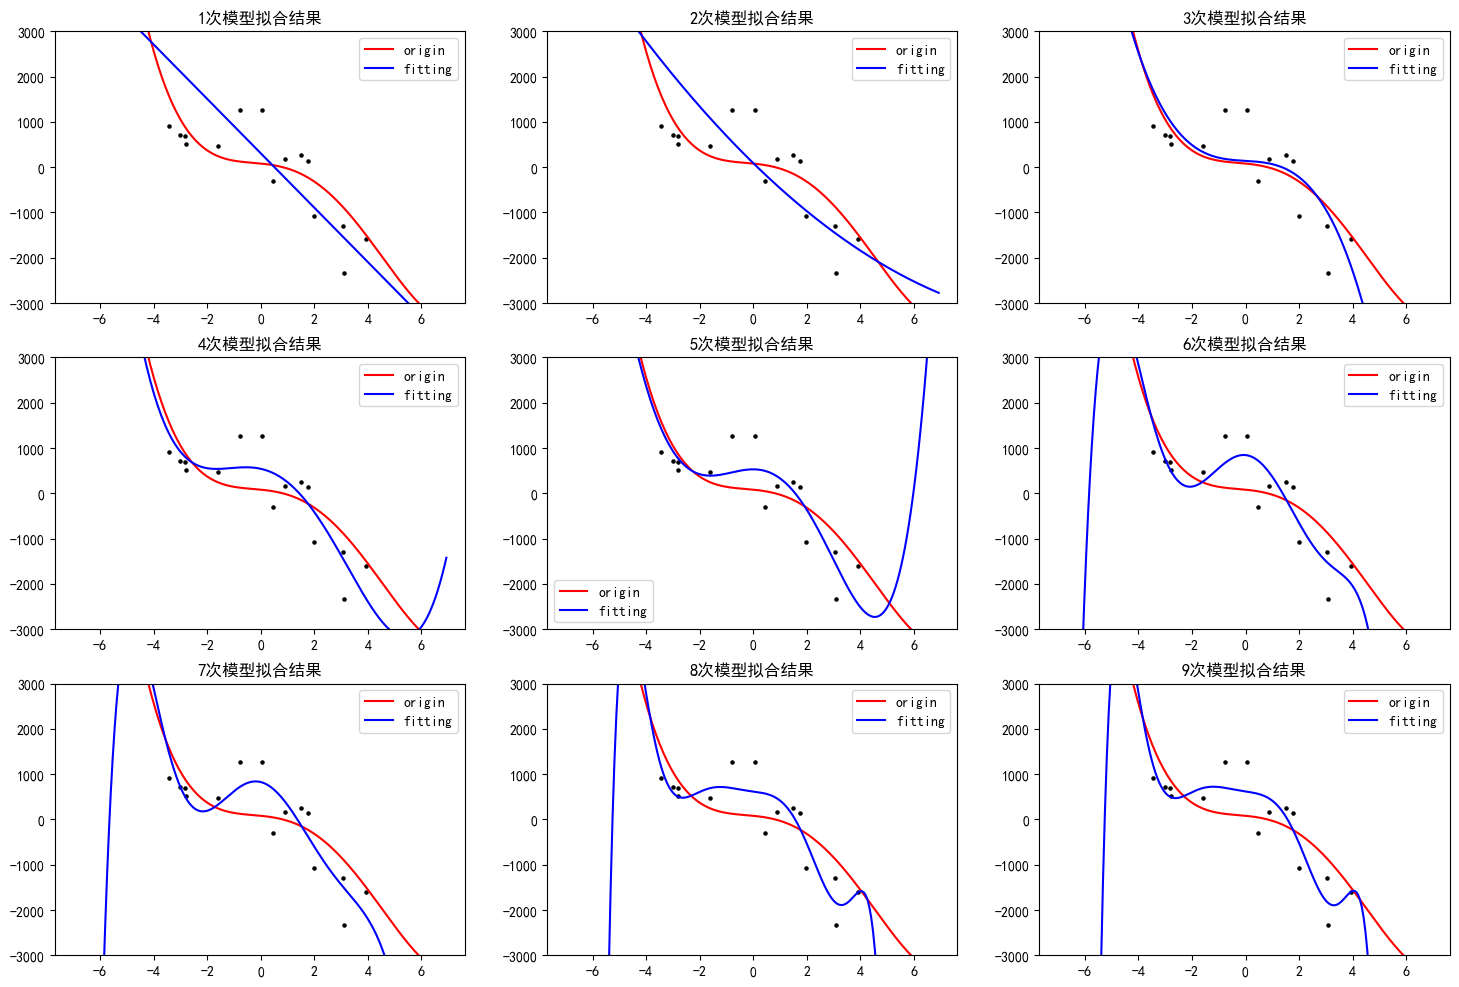

In [22]:
# 清除加入的约束
model.remove(model.getConstrs())

# 添加辅助变量将绝对值线性化
B = model.addVars(max_degree + 1, lb=-COPT.INFINITY, nameprefix='B')
model.addConstrs(B[i] >= A[i] for i in range(max_degree))
model.addConstrs(B[i] >= -A[i] for i in range(max_degree))

# 改变约束，添加正则化项
model.setObjective(cp.quicksum((points_y[i] - predict_num[i]) * (points_y[i] - predict_num[i]) for i in range(num_points))
                   + cp.quicksum(B[i] for i in range(10)) * lbd, sense=COPT.MINIMIZE)

# 设定子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 重复九次求解九个模型分别拟合1次到9次函数
for i in range(9, 0, -1):
    # 九次模型不需要加约束
    if i < 9:
        model.addConstr(A[8 - i] == 0)
    model.solve()
    print(f'\n{i}次模型相关信息')
    if model.status == COPT.OPTIMAL:
        print(f'最小误差为{round(model.objval, 2)}')
        variables = model.getVars()
        print(f'常数项: {round(variables[9].x, 2)}')
        for j in range(1, i + 1):
            print(f'{j}次项系数: {round(variables[9 - j].x, 2)}')
        # 绘制子图
        sub = axs[int((i - 1) / 3), (i - 1) % 3]
        # 绘制点
        sub.scatter(points_x, points_y, c='black', s=5)
        # 绘制曲线
        max_x = 7
        min_x = -7
        num_points_cal = 200
        x_origin = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_origin = []
        for k in range(num_points_cal):
            y_origin.append(coeff[0])
            for j in range(model_degree):
                y_origin[-1] *= x_origin[k]
                y_origin[-1] += coeff[j + 1]
        sub.plot(x_origin, y_origin, c='red', label='origin')
        x_cal = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_cal = []
        for k in range(num_points_cal):
            y_cal.append(A[0].x)
            for j in range(max_degree):
                y_cal[-1] *= x_cal[k]
                y_cal[-1] += A[j + 1].x
        sub.plot(x_cal, y_cal, c='blue', label='fitting')
        sub.set_title(f'{i}次模型拟合结果')
        sub.legend()
        sub.set_ylim(-3000, 3000)
    else:
        print('未找到最优解')
plt.show()